In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/healthcare-dataset/healthcare_dataset.csv


Dataset Information:
Each column provides specific information about the patient, their admission, and the healthcare services provided, making this dataset suitable for various data analysis and modeling tasks in the healthcare domain. Here's a brief explanation of each column in the dataset -

- Name: This column represents the name of the patient associated with the healthcare record.
- Age: The age of the patient at the time of admission, expressed in years.
- Gender: Indicates the gender of the patient, either "Male" or "Female."
- Blood Type: The patient's blood type, which can be one of the common blood types (e.g., "A+", "O-", etc.).
- Medical Condition: This column specifies the primary medical condition or diagnosis associated with the patient, such as "Diabetes," "Hypertension," "Asthma," and more.
- Date of Admission: The date on which the patient was admitted to the healthcare facility.
- Doctor: The name of the doctor responsible for the patient's care during their admission.
- Hospital: Identifies the healthcare facility or hospital where the patient was admitted.
- Insurance Provider: This column indicates the patient's insurance provider, which can be one of several options, including "Aetna," "Blue Cross," "Cigna," "UnitedHealthcare," and "Medicare."
- Billing Amount: The amount of money billed for the patient's healthcare services during their admission. This is expressed as a floating-point number.
- Room Number: The room number where the patient was accommodated during their admission.
Admission Type: Specifies the type of admission, which can be "Emergency," "Elective," or "Urgent," reflecting the circumstances of the admission.
- Discharge Date: The date on which the patient was discharged from the healthcare facility, based on the admission date and a random number of days within a realistic range.
- Medication: Identifies a medication prescribed or administered to the patient during their admission. Examples include "Aspirin," "Ibuprofen," "Penicillin," "Paracetamol," and "Lipitor."
- Test Results: Describes the results of a medical test conducted during the patient's admission. Possible values include "Normal," "Abnormal," or "Inconclusive," indicating the outcome of the test.

In [3]:
df = pd.read_csv("/kaggle/input/healthcare-dataset/healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [5]:
print(df.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [6]:
print(df['Test Results'].value_counts())

Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64


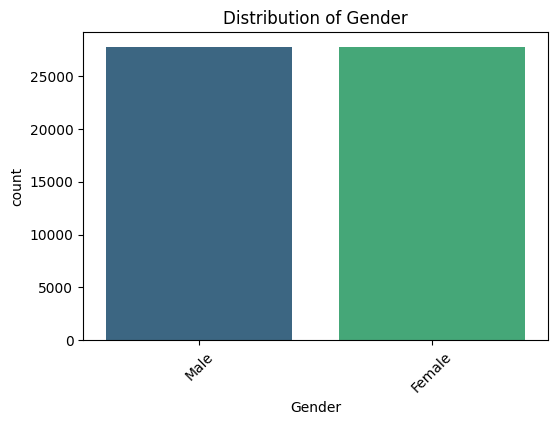

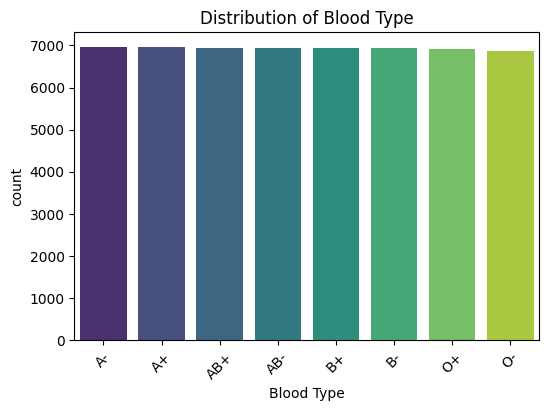

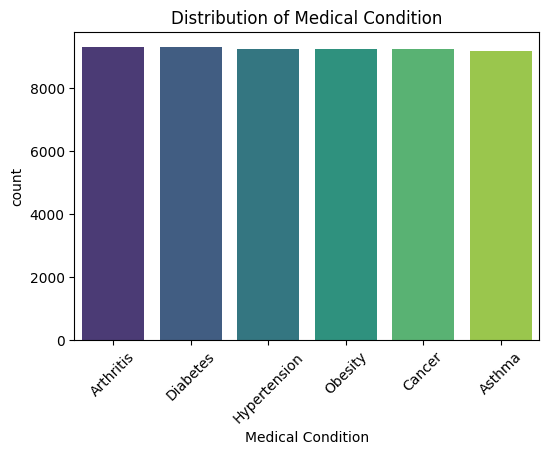

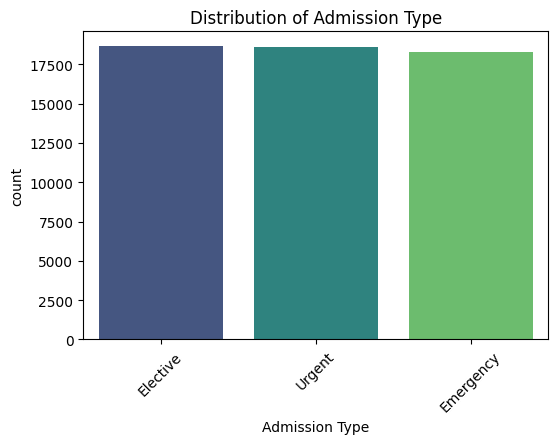

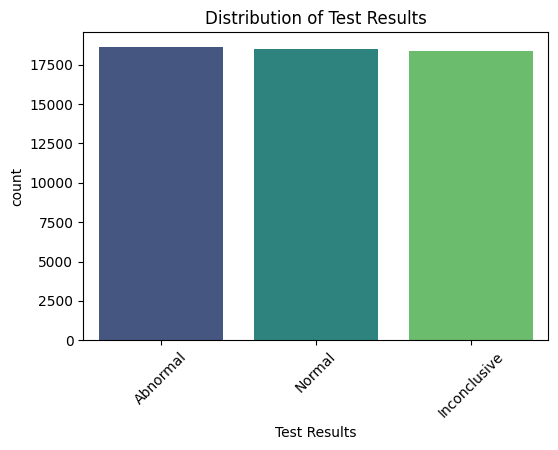

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = ['Gender', 'Blood Type', 'Medical Condition', 'Admission Type', 'Test Results']
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='viridis')
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()



/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


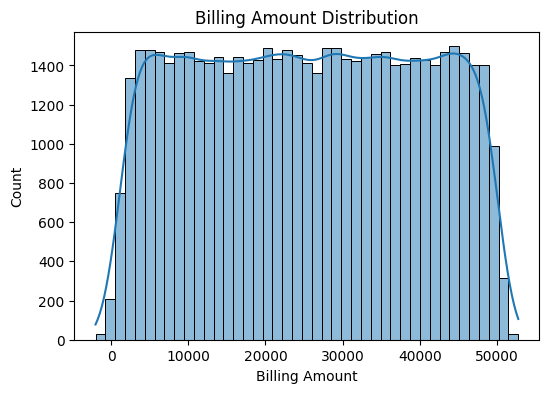

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df['Billing Amount'], kde=True)
plt.title("Billing Amount Distribution")
plt.show()


In [10]:
# Drop non-informative columns (like Name, Doctor, Room Number, Hospital)
drop_cols = ['Name', 'Doctor', 'Hospital', 'Room Number', 'Date of Admission', 'Discharge Date']
df = df.drop(columns=drop_cols)


In [11]:
df

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results
0,30,Male,B-,Cancer,Blue Cross,18856.281306,Urgent,Paracetamol,Normal
1,62,Male,A+,Obesity,Medicare,33643.327287,Emergency,Ibuprofen,Inconclusive
2,76,Female,A-,Obesity,Aetna,27955.096079,Emergency,Aspirin,Normal
3,28,Female,O+,Diabetes,Medicare,37909.782410,Elective,Ibuprofen,Abnormal
4,43,Female,AB+,Cancer,Aetna,14238.317814,Urgent,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...
55495,42,Female,O+,Asthma,Blue Cross,2650.714952,Elective,Penicillin,Abnormal
55496,61,Female,AB-,Obesity,Cigna,31457.797307,Elective,Aspirin,Normal
55497,38,Female,B+,Hypertension,UnitedHealthcare,27620.764717,Urgent,Ibuprofen,Abnormal
55498,43,Male,O-,Arthritis,Medicare,32451.092358,Elective,Ibuprofen,Abnormal


In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [13]:
df

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results
0,30,1,5,2,1,18856.281306,2,3,2
1,62,1,0,5,3,33643.327287,1,1,1
2,76,0,1,5,0,27955.096079,1,0,2
3,28,0,6,3,3,37909.782410,0,1,0
4,43,0,2,2,0,14238.317814,2,4,0
...,...,...,...,...,...,...,...,...,...
55495,42,0,6,1,1,2650.714952,0,4,0
55496,61,0,3,5,2,31457.797307,0,0,2
55497,38,0,4,4,4,27620.764717,2,1,0
55498,43,1,7,0,3,32451.092358,0,1,0


In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('Test Results', axis=1)
y = df['Test Results']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [20]:
from sklearn.svm import SVC
svm_clf = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)


SVC(C=10, random_state=42)

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = svm_clf.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Accuracy: 0.34675675675675677

Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.36      0.35      3754
           1       0.34      0.34      0.34      3617
           2       0.35      0.34      0.34      3729

    accuracy                           0.35     11100
   macro avg       0.35      0.35      0.35     11100
weighted avg       0.35      0.35      0.35     11100



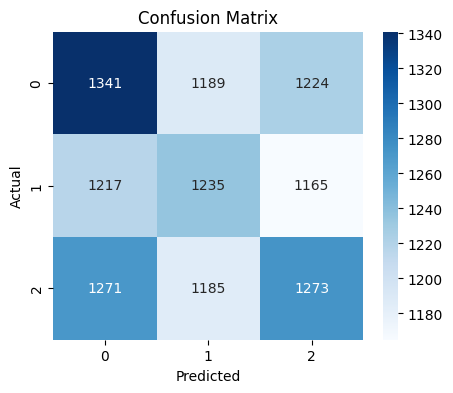

In [22]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


In [24]:
model_results = {}


Logistic Regression Accuracy: 0.3380
              precision    recall  f1-score   support

           0       0.35      0.34      0.34      3754
           1       0.33      0.32      0.32      3617
           2       0.34      0.36      0.35      3729

    accuracy                           0.34     11100
   macro avg       0.34      0.34      0.34     11100
weighted avg       0.34      0.34      0.34     11100



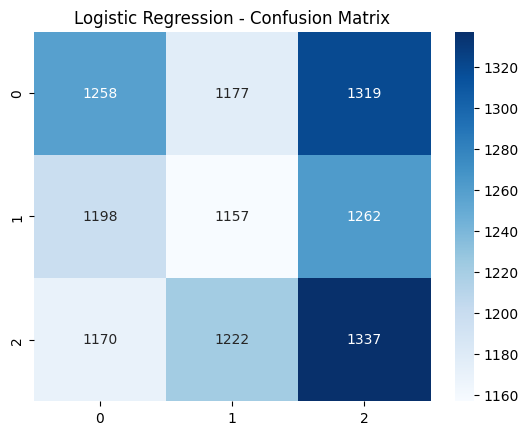

In [25]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=500, random_state=42)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

acc = accuracy_score(y_test, y_pred)
model_results["Logistic Regression"] = acc

print(f"Logistic Regression Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


Decision Tree Accuracy: 0.3948
              precision    recall  f1-score   support

           0       0.40      0.40      0.40      3754
           1       0.39      0.39      0.39      3617
           2       0.40      0.40      0.40      3729

    accuracy                           0.39     11100
   macro avg       0.39      0.39      0.39     11100
weighted avg       0.39      0.39      0.39     11100



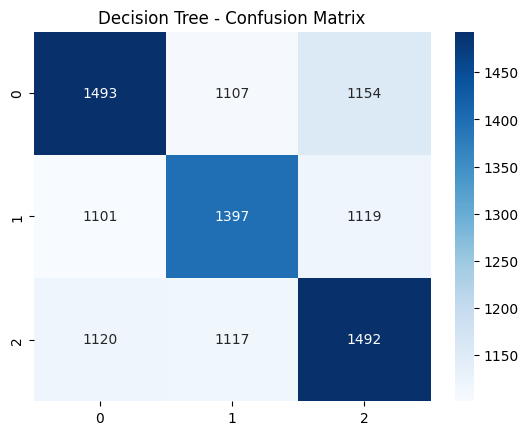

In [26]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

acc = accuracy_score(y_test, y_pred)
model_results["Decision Tree"] = acc

print(f"Decision Tree Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree - Confusion Matrix")
plt.show()


Random Forest Accuracy: 0.4341
              precision    recall  f1-score   support

           0       0.43      0.44      0.43      3754
           1       0.43      0.43      0.43      3617
           2       0.44      0.43      0.44      3729

    accuracy                           0.43     11100
   macro avg       0.43      0.43      0.43     11100
weighted avg       0.43      0.43      0.43     11100



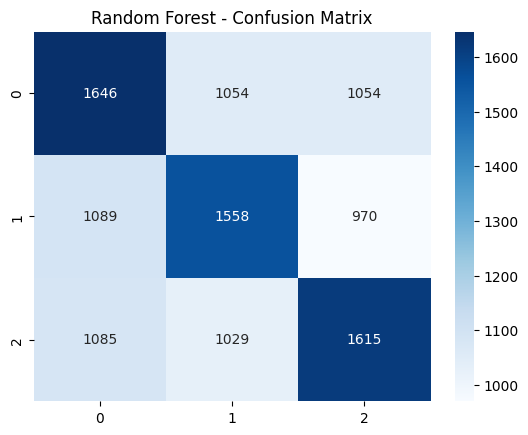

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
model_results["Random Forest"] = acc

print(f"Random Forest Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest - Confusion Matrix")
plt.show()


XGBoost Accuracy: 0.3555
              precision    recall  f1-score   support

           0       0.35      0.36      0.36      3754
           1       0.36      0.36      0.36      3617
           2       0.36      0.34      0.35      3729

    accuracy                           0.36     11100
   macro avg       0.36      0.36      0.36     11100
weighted avg       0.36      0.36      0.36     11100



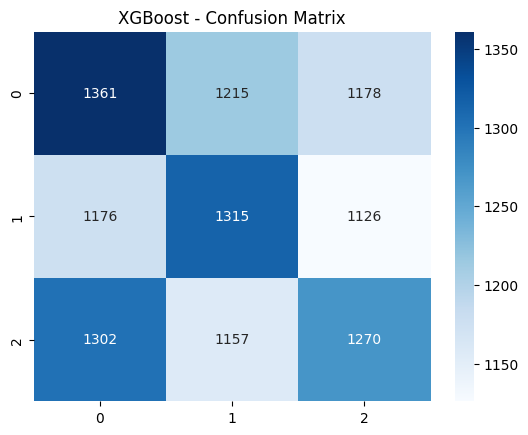

In [28]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

acc = accuracy_score(y_test, y_pred)
model_results["XGBoost"] = acc

print(f"XGBoost Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost - Confusion Matrix")
plt.show()


KNN Accuracy: 0.3671
              precision    recall  f1-score   support

           0       0.36      0.48      0.41      3754
           1       0.36      0.37      0.36      3617
           2       0.38      0.26      0.31      3729

    accuracy                           0.37     11100
   macro avg       0.37      0.37      0.36     11100
weighted avg       0.37      0.37      0.36     11100



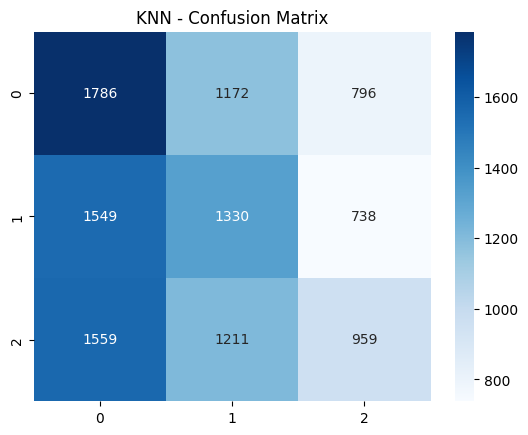

In [29]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
model_results["KNN"] = acc

print(f"KNN Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("KNN - Confusion Matrix")
plt.show()


SVM Accuracy: 0.3415
              precision    recall  f1-score   support

           0       0.34      0.37      0.35      3754
           1       0.34      0.34      0.34      3617
           2       0.35      0.32      0.33      3729

    accuracy                           0.34     11100
   macro avg       0.34      0.34      0.34     11100
weighted avg       0.34      0.34      0.34     11100



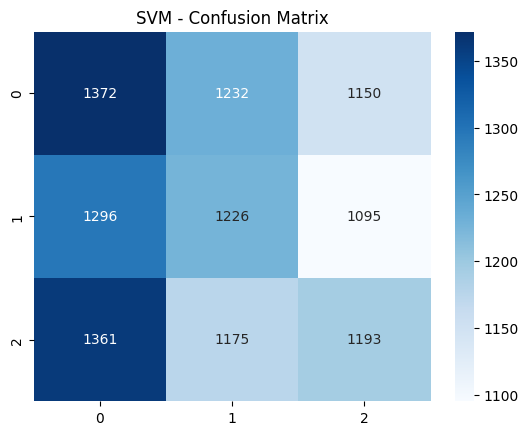

In [30]:
from sklearn.svm import SVC

svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)
y_pred = svm_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
model_results["SVM"] = acc

print(f"SVM Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("SVM - Confusion Matrix")
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


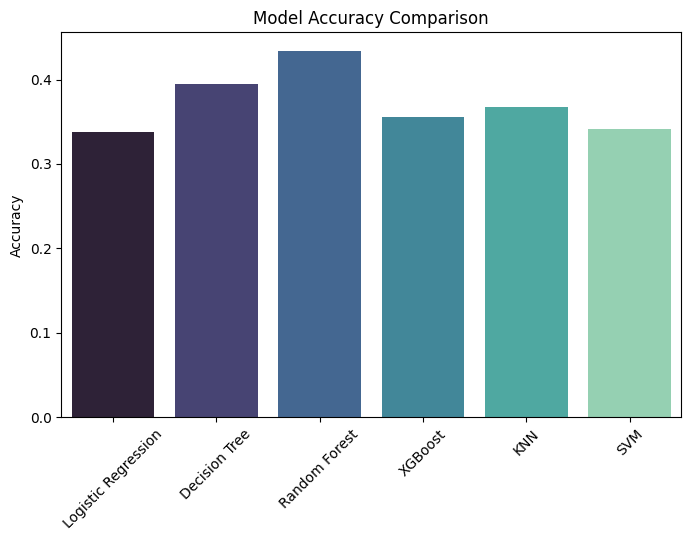


Accuracy Summary:
Logistic Regression: 0.3380
Decision Tree: 0.3948
Random Forest: 0.4341
XGBoost: 0.3555
KNN: 0.3671
SVM: 0.3415


In [31]:
plt.figure(figsize=(8,5))
sns.barplot(x=list(model_results.keys()), y=list(model_results.values()), palette='mako')
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

print("\nAccuracy Summary:")
for model, acc in model_results.items():
    print(f"{model}: {acc:.4f}")


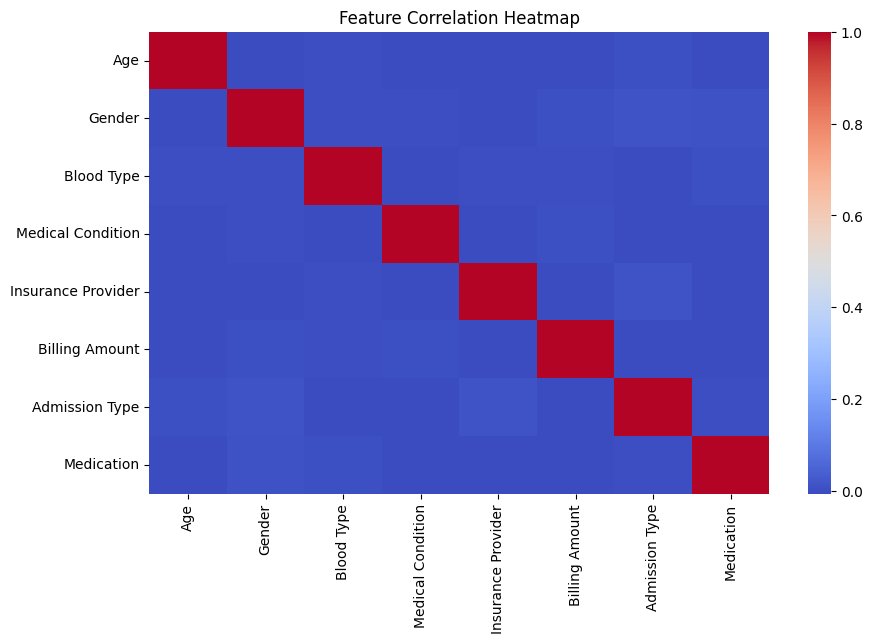

In [32]:
plt.figure(figsize=(10,6))
sns.heatmap(pd.DataFrame(X, columns=df.drop('Test Results', axis=1).columns).corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()
